In [1]:
!pip install librosa soundfile tqdm imbalanced-learn joblib --quiet

In [2]:
import os
import zipfile
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import librosa
import librosa.display

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold
)

from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    ConfusionMatrixDisplay
)

from imblearn.under_sampling import RandomUnderSampler

import joblib

In [3]:
from google.colab import files

uploaded = files.upload()

Saving heart_murmur.zip to heart_murmur.zip


In [13]:
zip_path="/content/heart_murmur.zip"

with zipfile.ZipFile(zip_path,'r') as zip_ref:
    zip_ref.extractall("/content")

print("Dataset Extracted Successfully!")

Dataset Extracted Successfully!


In [15]:
import os

ROOT = "/content/training_data"

In [37]:
CSV_PATH = "/content/training_data.csv"

# WAV files are inside this folder
audio_folder = "/content/training_data/training_data"

In [38]:
import os

for root, dirs, files in os.walk("/content"):
    print(root)
    for f in files[:5]:   # show first few files
        print("   ", f)

/content
    LICENSE.txt
    heart_murmur.zip
    RECORDS
    SHA256SUMS.txt
    training_data.csv
/content/.config
    config_sentinel
    active_config
    gce
    .last_opt_in_prompt.yaml
    default_configs.db
/content/.config/logs
/content/.config/logs/2026.06.04
    13.32.21.210570.log
    13.32.39.344962.log
    13.31.42.499627.log
    13.32.18.735754.log
    13.32.38.346437.log
/content/.config/configurations
    config_default
/content/training_data
/content/training_data/training_data
    50113_TV.tsv
    68337_TV.wav
    39043_MV.tsv
    49850.txt
    50771_MV.wav
/content/sample_data
    README.md
    anscombe.json
    mnist_test.csv
    mnist_train_small.csv
    california_housing_test.csv


In [39]:
df = pd.read_csv(CSV_PATH)

print(df.shape)

df.head()

(942, 22)


,Patient ID,Locations,Age,Sex,Height,Weight,Pregnancy status,Murmur,Murmur locations,Most audible location,...,Systolic murmur grading,Systolic murmur pitch,Systolic murmur quality,Diastolic murmur timing,Diastolic murmur shape,Diastolic murmur grading,Diastolic murmur pitch,Diastolic murmur quality,Campaign,Additional ID
0,2530,AV+PV+TV+MV,Child,Female,98.0,15.9,False,Absent,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CC2015,NaN
1,9979,AV+PV+TV+MV,Child,Female,103.0,13.1,False,Present,AV+MV+PV+TV,TV,...,III/VI,High,Harsh,NaN,NaN,NaN,NaN,NaN,CC2015,NaN
2,9983,AV+PV+TV+MV,Child,Male,115.0,19.1,False,Unknown,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CC2015,NaN
3,13918,AV+PV+TV+MV,Child,Male,98.0,15.9,False,Present,TV,TV,...,I/VI,Low,Blowing,NaN,NaN,NaN,NaN,NaN,CC2015,NaN
4,14241,AV+PV+TV+MV,Child,Male,87.0,11.2,False,Present,AV+MV+PV+TV,PV,...,II/VI,Low,Harsh,NaN,NaN,NaN,NaN,NaN,CC2015,NaN


In [40]:
df = df[df["Murmur"] != "Unknown"]

df["Label"] = df["Murmur"].map({

    "Absent":0,

    "Present":1

})

print(df["Label"].value_counts())

Label
0    695
1    179
Name: count, dtype: int64


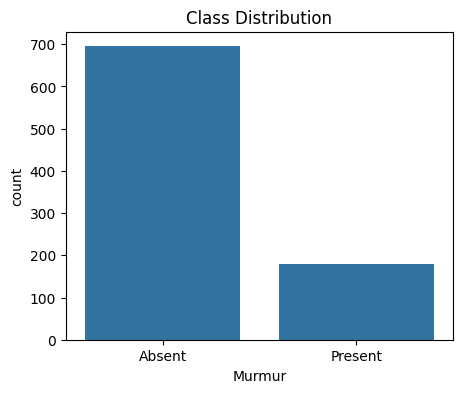

In [41]:
plt.figure(figsize=(5,4))

sns.countplot(
    x="Murmur",
    data=df
)

plt.title("Class Distribution")

plt.show()

In [42]:
print(df.isnull().sum())

Patient ID                    0
Locations                     0
Age                          72
Sex                           0
Height                      109
Weight                       99
Pregnancy status              0
Murmur                        0
Murmur locations            695
Most audible location       695
Systolic murmur timing      696
Systolic murmur shape       696
Systolic murmur grading     696
Systolic murmur pitch       696
Systolic murmur quality     696
Diastolic murmur timing     869
Diastolic murmur shape      869
Diastolic murmur grading    869
Diastolic murmur pitch      869
Diastolic murmur quality    869
Campaign                      0
Additional ID               747
Label                         0
dtype: int64


In [48]:
DATASET_PATH = "/content/training_data/training_data"
audio_folder = DATASET_PATH

In [49]:
TARGET_SR = 4000

WINDOW_DURATION = 5

WINDOW_SAMPLES = TARGET_SR * WINDOW_DURATION

In [50]:
def preprocess_audio(audio_path):

    signal, sr = librosa.load(

        audio_path,

        sr=TARGET_SR

    )

    signal = librosa.util.normalize(signal)

    # Crop

    if len(signal) > WINDOW_SAMPLES:

        signal = signal[:WINDOW_SAMPLES]

    # Pad

    elif len(signal) < WINDOW_SAMPLES:

        signal = np.pad(

            signal,

            (0, WINDOW_SAMPLES-len(signal)),

            mode="constant"

        )

    return signal, sr

In [51]:
print(audio_folder)
print(os.path.exists(audio_folder))

/content/training_data/training_data
True


In [52]:
sample_audio = None

for file in os.listdir(audio_folder):

    if file.endswith(".wav"):

        sample_audio = os.path.join(audio_folder,file)

        break

audio,sr = preprocess_audio(sample_audio)

print(len(audio)/sr)

5.0


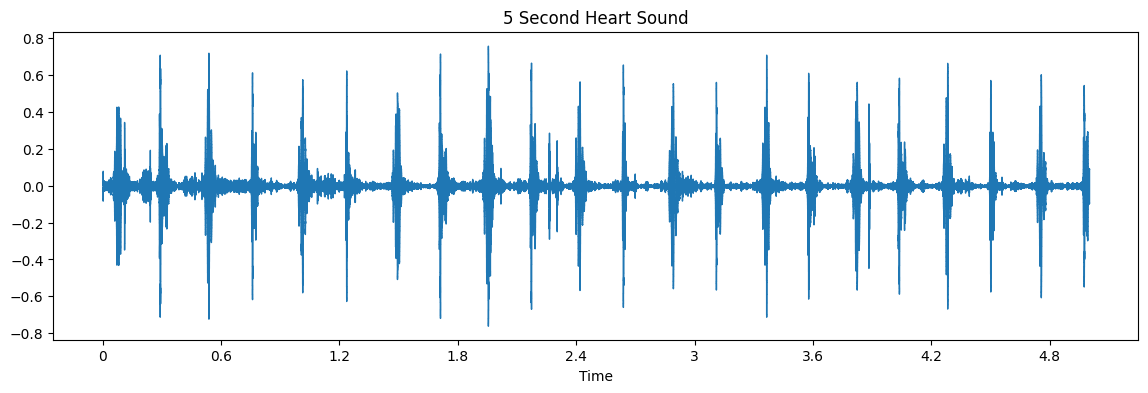

In [53]:
plt.figure(figsize=(14,4))

librosa.display.waveshow(

    audio,

    sr=sr

)

plt.title("5 Second Heart Sound")

plt.show()

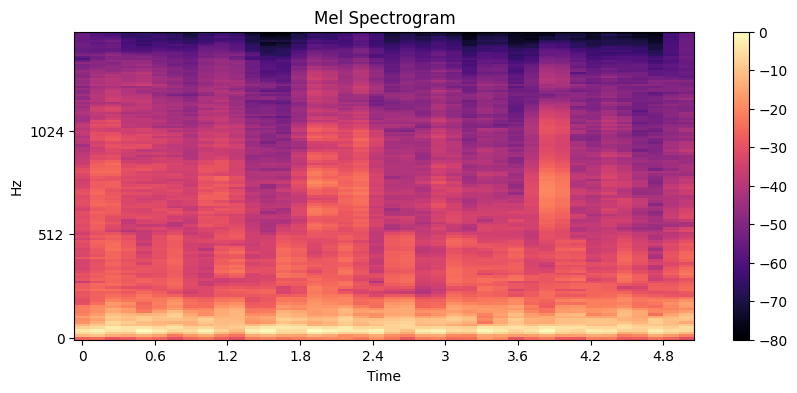

In [54]:
mel = librosa.feature.melspectrogram(

    y=audio,

    sr=sr

)

mel_db = librosa.power_to_db(

    mel,

    ref=np.max

)

plt.figure(figsize=(10,4))

librosa.display.specshow(

    mel_db,

    sr=sr,

    x_axis="time",

    y_axis="mel"

)

plt.colorbar()

plt.title("Mel Spectrogram")

plt.show()

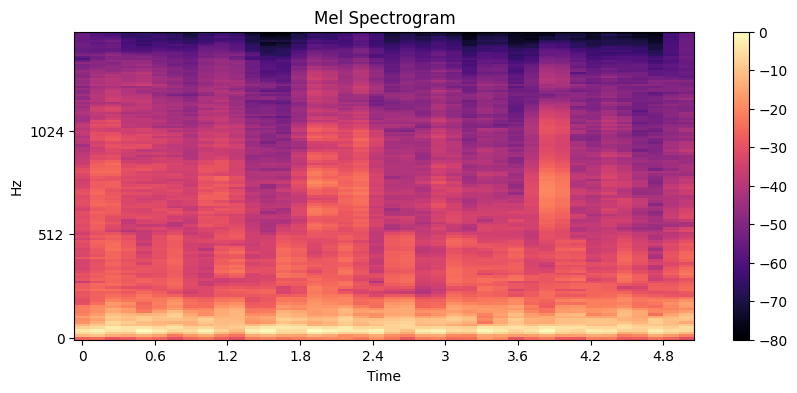

In [55]:
mel = librosa.feature.melspectrogram(

    y=audio,

    sr=sr

)

mel_db = librosa.power_to_db(

    mel,

    ref=np.max

)

plt.figure(figsize=(10,4))

librosa.display.specshow(

    mel_db,

    sr=sr,

    x_axis="time",

    y_axis="mel"

)

plt.colorbar()

plt.title("Mel Spectrogram")

plt.show()

In [64]:
def extract_features(audio_path):
    signal, sr = preprocess_audio(audio_path)

    zcr = np.mean(librosa.feature.zero_crossing_rate(signal))
    rms = np.mean(librosa.feature.rms(y=signal))

    mfcc = librosa.feature.mfcc(
        y=signal,
        sr=sr,
        n_mfcc=40
    )
    mfcc = np.mean(mfcc, axis=1)

    spectral_centroid = np.mean(
        librosa.feature.spectral_centroid(
            y=signal,
            sr=sr
        )
    )

    features = np.concatenate([
        [zcr],
        [rms],
        mfcc,
        [spectral_centroid]
    ])

    return features

In [65]:
features = []
labels = []

for _, row in tqdm(df.iterrows(), total=len(df)):

    patient_id = str(row["Patient ID"])

    patient_files = [

        f for f in os.listdir(audio_folder)

        if f.startswith(patient_id + "_") and f.endswith(".wav")

    ]

    for wav in patient_files:

        audio_path = os.path.join(audio_folder, wav)

        feature_vector = extract_features(audio_path)

        features.append(feature_vector)

        labels.append(row["Label"])

100%|██████████| 874/874 [00:59<00:00, 14.60it/s]


In [66]:
X = np.array(features)

y = np.array(labels)

print("Feature Matrix Shape :", X.shape)

print("Labels Shape :", y.shape)

Feature Matrix Shape : (3007, 43)
Labels Shape : (3007,)


In [67]:
pd.Series(y).value_counts()

,count
0,2391
1,616


In [68]:
print(X.shape)
print(y.shape)

(3007, 43)
(3007,)


In [69]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(

    random_state=42

)

X_balanced, y_balanced = rus.fit_resample(

    X,

    y

)

print(pd.Series(y_balanced).value_counts())

0    616
1    616
Name: count, dtype: int64


In [70]:
X_train, X_test, y_train, y_test = train_test_split(

    X_balanced,

    y_balanced,

    test_size=0.2,

    stratify=y_balanced,

    random_state=42

)

In [71]:
scaler = StandardScaler()

X_train = scaler.fit_transform(

    X_train

)

X_test = scaler.transform(

    X_test

)

In [72]:
print("Training Shape")

print(X_train.shape)

print()

print("Testing Shape")

print(X_test.shape)

Training Shape
(985, 43)

Testing Shape
(247, 43)


In [73]:
feature_names = (

    ["ZCR"]

    +

    ["RMS"]

    +

    [f"MFCC_{i+1}" for i in range(40)]

    +

    ["Spectral_Centroid"]

)

print(feature_names)

['ZCR', 'RMS', 'MFCC_1', 'MFCC_2', 'MFCC_3', 'MFCC_4', 'MFCC_5', 'MFCC_6', 'MFCC_7', 'MFCC_8', 'MFCC_9', 'MFCC_10', 'MFCC_11', 'MFCC_12', 'MFCC_13', 'MFCC_14', 'MFCC_15', 'MFCC_16', 'MFCC_17', 'MFCC_18', 'MFCC_19', 'MFCC_20', 'MFCC_21', 'MFCC_22', 'MFCC_23', 'MFCC_24', 'MFCC_25', 'MFCC_26', 'MFCC_27', 'MFCC_28', 'MFCC_29', 'MFCC_30', 'MFCC_31', 'MFCC_32', 'MFCC_33', 'MFCC_34', 'MFCC_35', 'MFCC_36', 'MFCC_37', 'MFCC_38', 'MFCC_39', 'MFCC_40', 'Spectral_Centroid']


In [75]:
rf = RandomForestClassifier(
    random_state=42
)

In [76]:
param_grid = {

    "n_estimators": [100, 200, 300],

    "max_depth": [10, 20, None],

    "min_samples_split": [2, 5],

    "min_samples_leaf": [1, 2],

    "max_features": ["sqrt", "log2"]

}

In [77]:
grid = GridSearchCV(

    estimator=rf,

    param_grid=param_grid,

    cv=5,

    scoring="f1",

    n_jobs=-1,

    verbose=2

)

grid.fit(

    X_train,

    y_train

)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20, None],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200, 300]},
             scoring='f1', verbose=2)

In [78]:
model = grid.best_estimator_

print("Best Parameters:\n")

print(grid.best_params_)

print("\nBest Cross Validation Score:")

print(grid.best_score_)

Best Parameters:

{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}

Best Cross Validation Score:
0.6250788250560839


In [79]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

In [80]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")

print(f"Precision : {precision:.4f}")

print(f"Recall : {recall:.4f}")

print(f"F1 Score : {f1:.4f}")

Accuracy : 0.6194
Precision : 0.6198
Recall : 0.6098
F1 Score : 0.6148


In [81]:
print(classification_report(

    y_test,

    y_pred,

    target_names=["Absent","Present"]

))

              precision    recall  f1-score   support

      Absent       0.62      0.63      0.62       124
     Present       0.62      0.61      0.61       123

    accuracy                           0.62       247
   macro avg       0.62      0.62      0.62       247
weighted avg       0.62      0.62      0.62       247



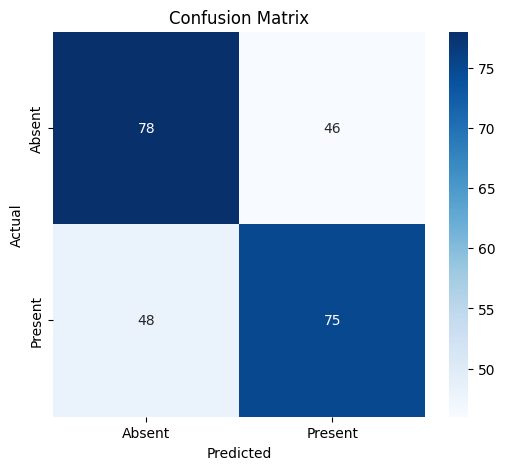

In [82]:
cm = confusion_matrix(

    y_test,

    y_pred

)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=["Absent","Present"],

    yticklabels=["Absent","Present"]

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

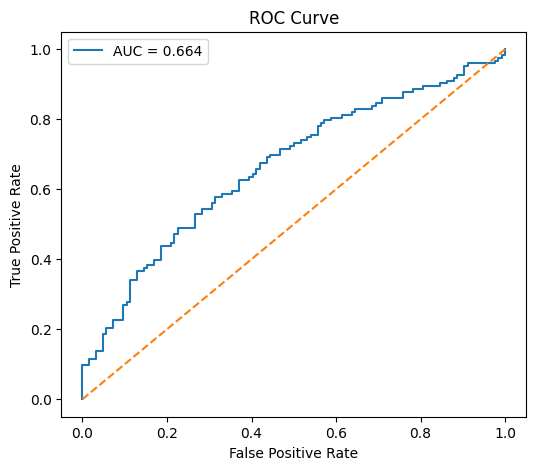

In [83]:
fpr, tpr, thresholds = roc_curve(

    y_test,

    y_prob

)

roc_auc = auc(

    fpr,

    tpr

)

plt.figure(figsize=(6,5))

plt.plot(

    fpr,

    tpr,

    label=f"AUC = {roc_auc:.3f}"

)

plt.plot(

    [0,1],

    [0,1],

    "--"

)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [84]:
importance = model.feature_importances_

importance_df = pd.DataFrame({

    "Feature":feature_names,

    "Importance":importance

})

importance_df = importance_df.sort_values(

    by="Importance",

    ascending=False

)

importance_df.head(15)

,Feature,Importance
2,MFCC_1,0.044074
3,MFCC_2,0.042589
1,RMS,0.036701
7,MFCC_6,0.033289
14,MFCC_13,0.032206
12,MFCC_11,0.031424
0,ZCR,0.030252
15,MFCC_14,0.027662
13,MFCC_12,0.027130
8,MFCC_7,0.026620


In [85]:
joblib.dump(

    model,

    "heart_murmur_random_forest.pkl"

)

joblib.dump(

    scaler,

    "scaler.pkl"

)

print("Model Saved Successfully")

Model Saved Successfully
